In [2]:
import pandas as pd
import numpy as np

In [6]:
df=pd.read_csv("WineQT.csv")

In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [8]:
df.shape

(1143, 13)

In [9]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [11]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [12]:
df["quality"].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

In [13]:
sns.countplot(x="quality", data=df)

plt.show()

NameError: name 'sns' is not defined

In [14]:
import seaborn as sns 
import matplotlib.pyplot as plt

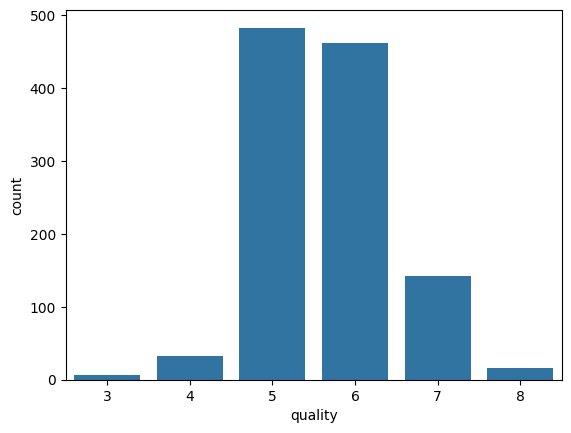

In [15]:
sns.countplot(x="quality", data=df)

plt.show()

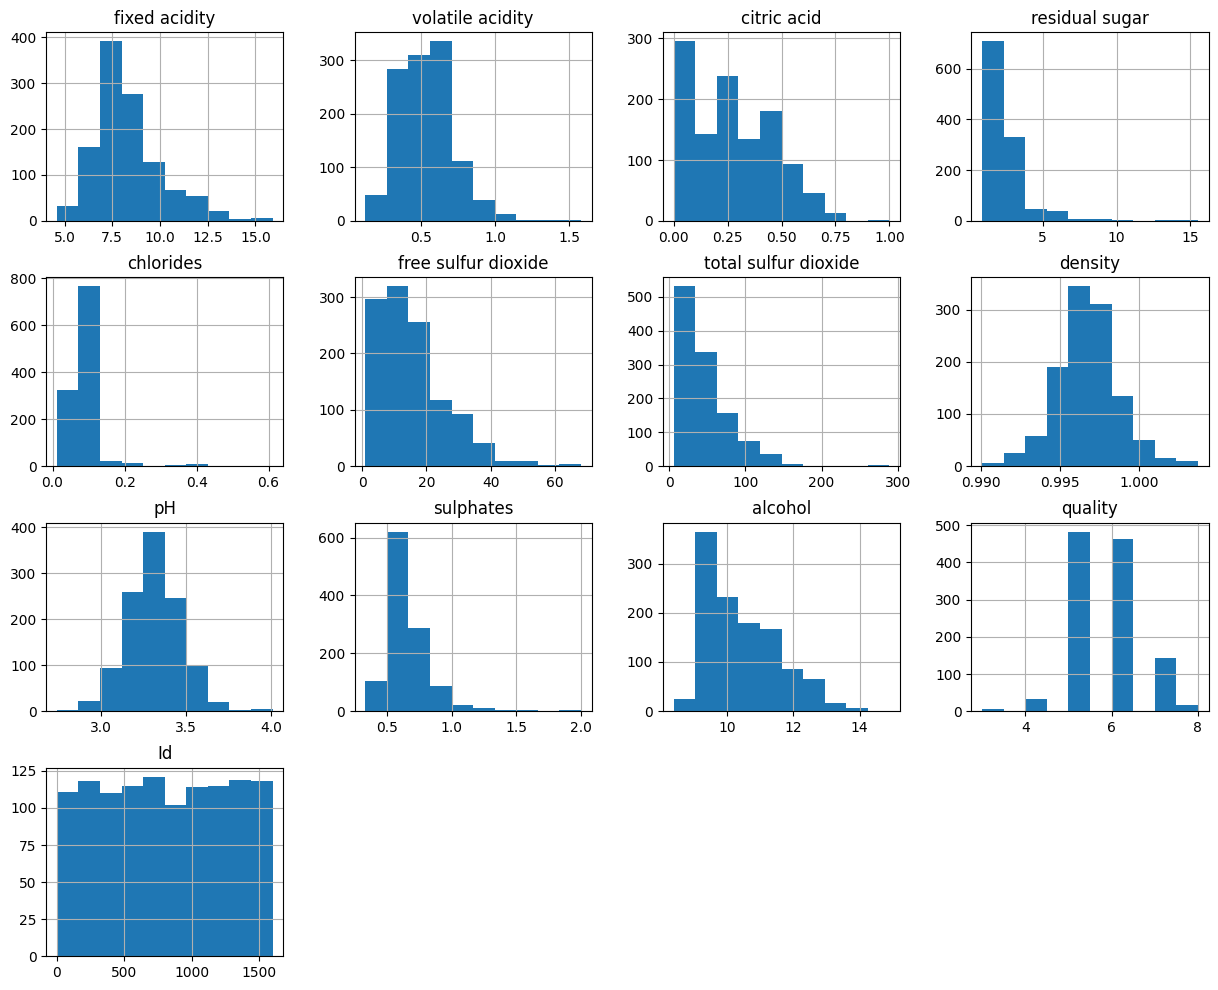

In [16]:
df.hist(figsize=(15,12))

plt.show()

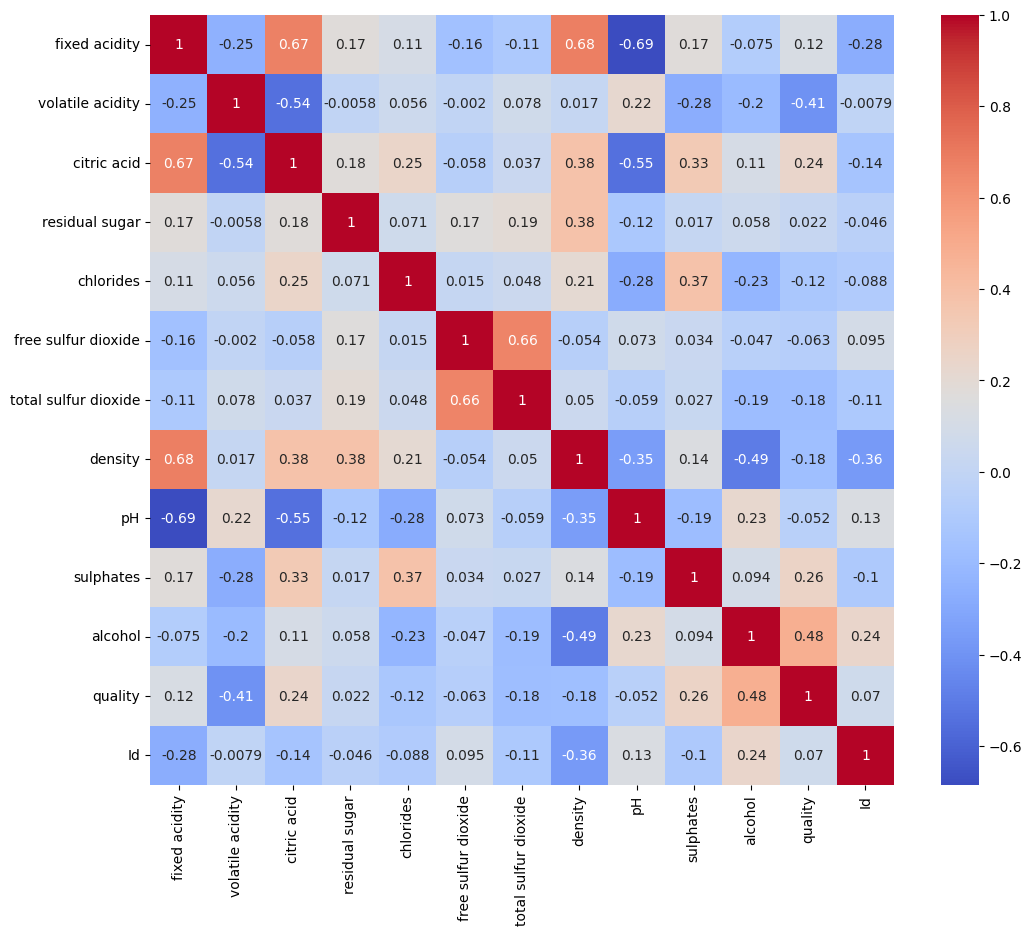

In [17]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.show()

In [18]:
df["quality"]=df["quality"].apply(lambda x:1 if x>=6 else 0)

In [19]:
X=df.drop("quality",axis=1)

y=df["quality"]

In [23]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4


In [24]:
y.head()

0    0
1    0
2    0
3    1
4    0
Name: quality, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print (X_train.shape)
print(X_test.shape)

(914, 12)
(229, 12)


In [31]:
from sklearn.linear_model import SGDClassifier

In [32]:
import sklearn
print(sklearn.__version__)

1.9.0


In [33]:
import sys
print(sys.version)

3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [34]:
from sklearn.svm import SVC

In [35]:
from sklearn.ensemble._forest import RandomForestClassifier

In [36]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [37]:
rf_pred=rf.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.8122270742358079


In [41]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       105
           1       0.81      0.85      0.83       124

    accuracy                           0.81       229
   macro avg       0.81      0.81      0.81       229
weighted avg       0.81      0.81      0.81       229



In [42]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[ 80  25]
 [ 18 106]]


In [43]:
accuracy_score(y_test,rf_pred)

0.8122270742358079

In [44]:
rf_pred=rf.predict(X_test)

In [45]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       105
           1       0.81      0.85      0.83       124

    accuracy                           0.81       229
   macro avg       0.81      0.81      0.81       229
weighted avg       0.81      0.81      0.81       229



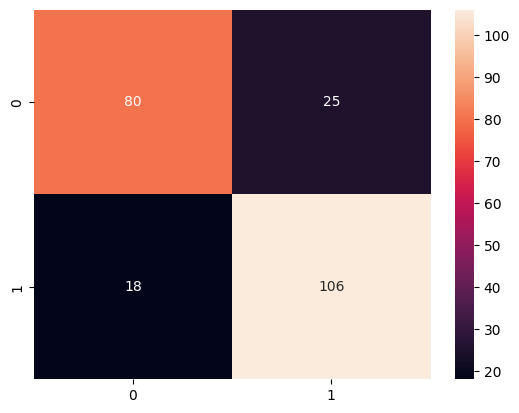

In [46]:
cm=confusion_matrix(y_test,rf_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.show()

In [47]:
sgd=SGDClassifier(random_state=42)

sgd.fit(X_train,y_train)

sgd_pred=sgd.predict(X_test)

In [48]:
accuracy_score(y_test,sgd_pred)

0.5414847161572053

In [49]:
print(classification_report(y_test,sgd_pred))

              precision    recall  f1-score   support

           0       0.50      0.08      0.13       105
           1       0.54      0.94      0.69       124

    accuracy                           0.54       229
   macro avg       0.52      0.51      0.41       229
weighted avg       0.52      0.54      0.43       229



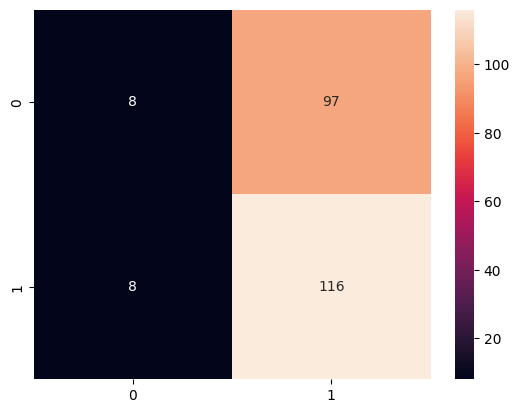

In [50]:
cm=confusion_matrix(y_test,sgd_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.show()

In [51]:
svc=SVC()

svc.fit(X_train,y_train)

svc_pred=svc.predict(X_test)

In [52]:
accuracy_score(y_test,svc_pred)

0.5720524017467249

In [53]:
print(classification_report(y_test,svc_pred))

              precision    recall  f1-score   support

           0       0.59      0.22      0.32       105
           1       0.57      0.87      0.69       124

    accuracy                           0.57       229
   macro avg       0.58      0.55      0.50       229
weighted avg       0.58      0.57      0.52       229



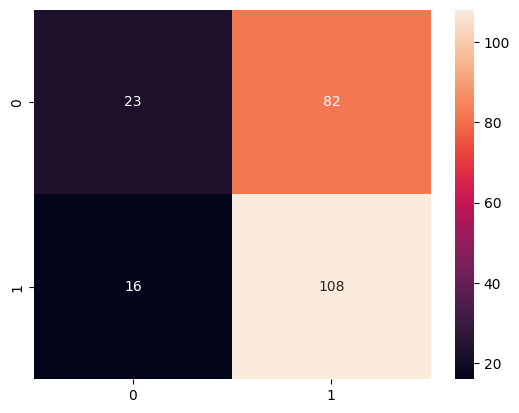

In [54]:
cm=confusion_matrix(y_test,svc_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.show()

In [55]:
importance=rf.feature_importances_

In [56]:
feature=pd.DataFrame({
"Feature":X.columns,
"Importance":importance
})

In [57]:
feature=feature.sort_values("Importance",ascending=False)

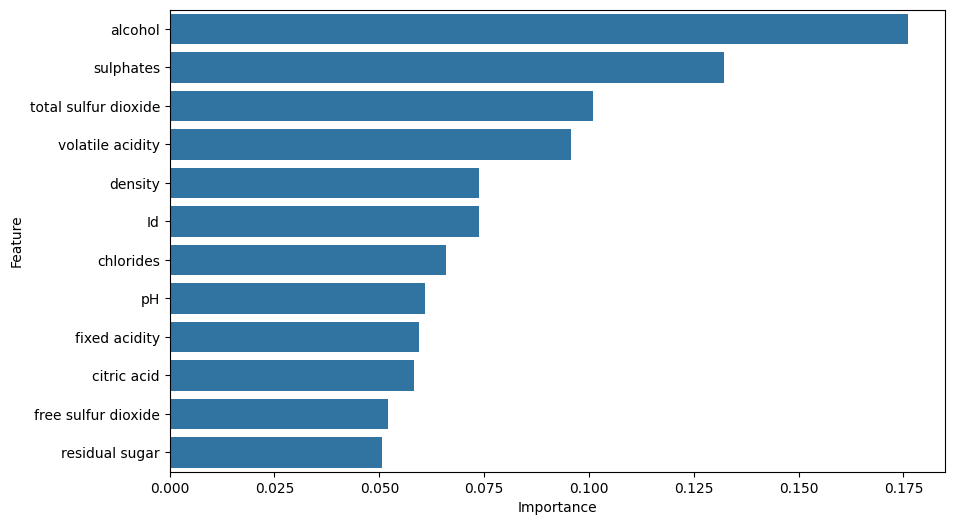

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(x="Importance",y="Feature",data=feature)

plt.show()

Alcohol

Sulphates

Volatile Acidity

are among the most important features.

In [59]:
comparison=pd.DataFrame({
"Model":["Random Forest","SGD","SVC"],
"Accuracy":[
accuracy_score(y_test,rf_pred),
accuracy_score(y_test,sgd_pred),
accuracy_score(y_test,svc_pred)
]
})

comparison

,Model,Accuracy
0,Random Forest,0.812227
1,SGD,0.541485
2,SVC,0.572052
